<a href="https://colab.research.google.com/github/evaayobi/mobile-money-fraud-detector/blob/main/Mobile_Money_Fraud_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Mobile Money Fraud Detector
 AI/ML Capstone Project

Nigerian problem context: Mobile-money agents (MTN MoMo, OPay, PalmPay, Moniepoint, Airtel Money, etc.) process millions of cash-in/cash-out, transfer, airtime and bill-payment transactions every day. Agents and platforms are routinely targeted by fraud rings — SIM-swap account takeovers, structuring transactions to dodge reporting thresholds, mule-account layering, and agent-till ledger manipulation — often losing agents their own float or exposing platforms to regulatory penalties under the CBN's mobile money guidelines.

Goal (MVP): given a transaction, flag whether it is likely fraudulent and produce an anomaly score an agent, risk analyst, or downstream system can act on in real time.

Pipeline overview
1. Load / generate transaction data
2. Exploratory data analysis (EDA)
3. Feature engineering (fraud-typology signals)
4. Train/test split
5. Model A — Isolation Forest (unsupervised anomaly score)
6. Model B — supervised classifiers (Logistic Regression baseline + Random Forest)
7. Evaluation (precision, recall, F1, ROC-AUC, PR-AUC, confusion matrix)
8. Save trained model + build a reusable `predict(transaction)` inference function
9. Sample end-to-end inference demo

> This notebook is self-contained and runs top-to-bottom in Google Colab. Outputs shown below are from an actual run of this pipeline.

## 1. Setup

In [1]:


import json
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 30)
RNG_SEED = 42
np.random.seed(RNG_SEED)
print("Environment ready.")

Environment ready.


 2. Data

There is no public, unrestricted transaction-level dataset from a Nigerian mobile-money operator — that data is commercially sensitive and covered by the NDPR (Nigeria Data Protection Regulation). This notebook generates a synthetic but behaviourally realistic dataset: a population of agents and customers, everyday legitimate transaction behaviour, and four labelled fraud typologies drawn from real-world mobile-money fraud reporting:

- Account takeover / SIM-swap cash-out spree — new device, odd hour, large cash-out, high transaction velocity.
- Structuring— several transactions just under the ₦100,000 reporting threshold in quick succession.
- Mule-account layering — a brand-new beneficiary receives a large transfer that is immediately cashed out.
- Agent till / ledger manipulation — the agent's before/after balances don't reconcile with the transaction amount.

The schema mirrors what a real agent-banking core system logs, so the same pipeline can be pointed at a real export with minimal changes — swap Section 2 for `pd.read_csv('your_export.csv')`.

In [2]:
import numpy as np
import pandas as pd

RNG_SEED = 42

STATES = [
    "Lagos", "Kano", "Rivers", "Oyo", "Anambra", "Kaduna", "Enugu",
    "Delta", "Edo", "Ogun", "Plateau", "Abuja (FCT)",
]

TX_TYPES = ["CASH_IN", "CASH_OUT", "TRANSFER", "AIRTIME", "BILL_PAYMENT"]
CHANNELS = ["AGENT_POS", "USSD", "MOBILE_APP"]

# Reporting/structuring threshold used by many NG mobile-money operators
STRUCTURING_THRESHOLD = 100_000  # NGN


def _make_population(n_agents=400, n_customers=6000, rng=None):
    rng = rng or np.random.default_rng(RNG_SEED)
    agents = pd.DataFrame({
        "agent_id": [f"AGT{100000+i}" for i in range(n_agents)],
        "agent_state": rng.choice(STATES, n_agents),
        "agent_avg_daily_volume": rng.lognormal(mean=11.5, sigma=0.6, size=n_agents),
    })
    customers = pd.DataFrame({
        "customer_id": [f"CUS{200000+i}" for i in range(n_customers)],
        "customer_home_state": rng.choice(STATES, n_customers),
    })
    return agents, customers


def generate_transactions(n_transactions=25_000, fraud_rate=0.025, seed=RNG_SEED):
    """Generate a labelled transaction dataset.

    Parameters
    ----------
    n_transactions : int
        Total number of transactions to generate.
    fraud_rate : float
        Approximate proportion of transactions that will be fraudulent
        (mobile-money fraud is a rare-event / class-imbalance problem,
        typically well under 5% of volume).
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    pd.DataFrame
    """
    rng = np.random.default_rng(seed)
    agents, customers = _make_population(rng=rng)

    n_fraud = int(n_transactions * fraud_rate)
    n_legit = n_transactions - n_fraud

    rows = []

    # ---------------------------------------------------------------
    # 1. Legitimate transaction population
    # ---------------------------------------------------------------
    for _ in range(n_legit):
        agent = agents.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        cust = customers.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        tx_type = rng.choice(TX_TYPES, p=[0.28, 0.28, 0.24, 0.12, 0.08])
        hour = int(np.clip(rng.normal(13, 4), 0, 23))
        channel = rng.choice(CHANNELS, p=[0.55, 0.30, 0.15])

        if tx_type in ("AIRTIME", "BILL_PAYMENT"):
            amount = round(rng.lognormal(mean=7.0, sigma=0.7), 2)
        else:
            amount = round(rng.lognormal(mean=9.7, sigma=1.0), 2)
        amount = float(np.clip(amount, 100, 500_000))

        old_bal_cust = round(rng.lognormal(mean=10.0, sigma=1.1), 2)
        if tx_type in ("CASH_IN", "TRANSFER") and rng.random() < 0.5:
            # receiving money
            new_bal_cust = old_bal_cust + amount
        else:
            new_bal_cust = max(0.0, old_bal_cust - amount)

        old_bal_agent = round(rng.lognormal(mean=12.0, sigma=0.7), 2)
        new_bal_agent = (old_bal_agent - amount) if tx_type == "CASH_OUT" else (old_bal_agent + amount)
        new_bal_agent = max(0.0, new_bal_agent)

        rows.append(dict(
            agent_id=agent["agent_id"],
            agent_state=agent["agent_state"],
            customer_id=cust["customer_id"],
            customer_home_state=cust["customer_home_state"],
            transaction_type=tx_type,
            channel=channel,
            hour_of_day=hour,
            amount=amount,
            old_balance_customer=old_bal_cust,
            new_balance_customer=new_bal_cust,
            old_balance_agent=old_bal_agent,
            new_balance_agent=new_bal_agent,
            is_new_beneficiary=int(rng.random() < 0.05),
            customer_tx_count_last_hour=int(np.clip(rng.poisson(1.0), 0, 15)),
            device_change_flag=int(rng.random() < 0.02),
            is_fraud=0,
        ))

    # ---------------------------------------------------------------
    # 2. Fraud typologies (roughly evenly split across 4 patterns)
    # ---------------------------------------------------------------
    n_each = n_fraud // 4

    # (a) Account-takeover / SIM-swap cash-out spree: new device, odd hour,
    #     large cash-out, high tx velocity, balance drained close to zero.
    for _ in range(n_each):
        agent = agents.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        cust = customers.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        hour = int(rng.choice([0, 1, 2, 3, 4, 22, 23]))
        old_bal_cust = round(rng.lognormal(mean=10.5, sigma=1.0), 2)
        amount = round(old_bal_cust * rng.uniform(0.85, 1.0), 2)
        new_bal_cust = max(0.0, old_bal_cust - amount)
        old_bal_agent = round(rng.lognormal(mean=12.0, sigma=0.7), 2)
        new_bal_agent = old_bal_agent - amount
        rows.append(dict(
            agent_id=agent["agent_id"], agent_state=agent["agent_state"],
            customer_id=cust["customer_id"], customer_home_state=cust["customer_home_state"],
            transaction_type="CASH_OUT", channel=rng.choice(["USSD", "MOBILE_APP"]),
            hour_of_day=hour, amount=amount,
            old_balance_customer=old_bal_cust, new_balance_customer=new_bal_cust,
            old_balance_agent=old_bal_agent, new_balance_agent=new_bal_agent,
            is_new_beneficiary=0,
            customer_tx_count_last_hour=int(np.clip(rng.poisson(6), 3, 20)),
            device_change_flag=1,
            is_fraud=1,
        ))

    # (b) Structuring: several transactions just under the reporting
    #     threshold in quick succession.
    for _ in range(n_each):
        agent = agents.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        cust = customers.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        amount = round(STRUCTURING_THRESHOLD * rng.uniform(0.90, 0.995), 2)
        old_bal_cust = round(rng.lognormal(mean=11.0, sigma=0.8), 2)
        new_bal_cust = max(0.0, old_bal_cust - amount)
        old_bal_agent = round(rng.lognormal(mean=12.0, sigma=0.7), 2)
        new_bal_agent = old_bal_agent + amount
        rows.append(dict(
            agent_id=agent["agent_id"], agent_state=agent["agent_state"],
            customer_id=cust["customer_id"], customer_home_state=cust["customer_home_state"],
            transaction_type="TRANSFER", channel=rng.choice(CHANNELS),
            hour_of_day=int(rng.integers(8, 20)), amount=amount,
            old_balance_customer=old_bal_cust, new_balance_customer=new_bal_cust,
            old_balance_agent=old_bal_agent, new_balance_agent=new_bal_agent,
            is_new_beneficiary=int(rng.random() < 0.6),
            customer_tx_count_last_hour=int(np.clip(rng.poisson(4), 2, 15)),
            device_change_flag=int(rng.random() < 0.1),
            is_fraud=1,
        ))

    # (c) Mule-account layering: brand-new beneficiary receives a large
    #     transfer, immediately cashed out.
    for _ in range(n_each):
        agent = agents.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        cust = customers.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        amount = round(rng.lognormal(mean=11.2, sigma=0.5), 2)
        amount = float(np.clip(amount, 150_000, 900_000))
        old_bal_cust = round(rng.uniform(0, 5000), 2)
        new_bal_cust = old_bal_cust  # money passes straight through
        old_bal_agent = round(rng.lognormal(mean=12.0, sigma=0.7), 2)
        new_bal_agent = old_bal_agent - amount
        rows.append(dict(
            agent_id=agent["agent_id"], agent_state=agent["agent_state"],
            customer_id=cust["customer_id"], customer_home_state=cust["customer_home_state"],
            transaction_type="CASH_OUT", channel=rng.choice(["AGENT_POS", "USSD"]),
            hour_of_day=int(rng.integers(6, 22)), amount=amount,
            old_balance_customer=old_bal_cust, new_balance_customer=new_bal_cust,
            old_balance_agent=old_bal_agent, new_balance_agent=new_bal_agent,
            is_new_beneficiary=1,
            customer_tx_count_last_hour=int(np.clip(rng.poisson(3), 1, 12)),
            device_change_flag=int(rng.random() < 0.4),
            is_fraud=1,
        ))

    # (d) Agent till/balance-manipulation fraud: agent-side balances do not
    #     reconcile with the transaction amount (classic ledger-tamper signal).
    n_last = n_fraud - 3 * n_each
    for _ in range(n_last):
        agent = agents.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        cust = customers.sample(1, random_state=rng.integers(0, 1_000_000)).iloc[0]
        amount = round(rng.lognormal(mean=10.3, sigma=0.9), 2)
        old_bal_cust = round(rng.lognormal(mean=10.0, sigma=1.0), 2)
        new_bal_cust = max(0.0, old_bal_cust - amount)
        old_bal_agent = round(rng.lognormal(mean=12.0, sigma=0.7), 2)
        # deliberately inconsistent agent ledger
        new_bal_agent = old_bal_agent + rng.uniform(-amount * 0.6, amount * 0.6)
        rows.append(dict(
            agent_id=agent["agent_id"], agent_state=agent["agent_state"],
            customer_id=cust["customer_id"], customer_home_state=cust["customer_home_state"],
            transaction_type="CASH_OUT", channel="AGENT_POS",
            hour_of_day=int(rng.integers(8, 21)), amount=amount,
            old_balance_customer=old_bal_cust, new_balance_customer=new_bal_cust,
            old_balance_agent=old_bal_agent, new_balance_agent=max(0.0, new_bal_agent),
            is_new_beneficiary=int(rng.random() < 0.2),
            customer_tx_count_last_hour=int(np.clip(rng.poisson(1.5), 0, 10)),
            device_change_flag=int(rng.random() < 0.15),
            is_fraud=1,
        ))

    df = pd.DataFrame(rows)
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    df.insert(0, "transaction_id", [f"TXN{1000000+i}" for i in range(len(df))])
    return df

In [3]:
df = generate_transactions(n_transactions=25_000, fraud_rate=0.025, seed=RNG_SEED)
os.makedirs("data", exist_ok=True)
df.to_csv("data/mobile_money_transactions.csv", index=False)

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean():.4%}  ({df['is_fraud'].sum():,} fraud / {len(df):,} total)")
df.head(3)

Shape: (25000, 17)
Fraud rate: 2.5000%  (625 fraud / 25,000 total)


,transaction_id,agent_id,agent_state,customer_id,customer_home_state,transaction_type,channel,hour_of_day,amount,old_balance_customer,new_balance_customer,old_balance_agent,new_balance_agent,is_new_beneficiary,customer_tx_count_last_hour,device_change_flag,is_fraud
0,TXN1000000,AGT100292,Abuja (FCT),CUS201087,Kano,TRANSFER,AGENT_POS,13,3740.94,52755.68,49014.74,122246.44,125987.38,0,3,0,0
1,TXN1000001,AGT100308,Oyo,CUS201134,Plateau,CASH_OUT,MOBILE_APP,15,29500.50,104951.57,75451.07,541850.60,512350.10,0,0,0,0
2,TXN1000002,AGT100104,Ogun,CUS205844,Kaduna,CASH_IN,AGENT_POS,16,21721.31,21675.77,43397.08,74653.83,96375.14,1,1,0,0


## 3. Exploratory Data Analysis

We check class imbalance (fraud is rare, as in production), which transaction types and channels carry the most fraud risk, and how fraud differs from legitimate activity in amount and timing — these observations directly motivate the engineered features in Section 4.

In [4]:
print("Transactions by type:")
print(df["transaction_type"].value_counts())

print("\nFraud rate by transaction type:")
print(df.groupby("transaction_type")["is_fraud"].mean().sort_values(ascending=False))

print("\nFraud rate by channel:")
print(df.groupby("channel")["is_fraud"].mean().sort_values(ascending=False))

Transactions by type:
transaction_type
CASH_OUT        7244
CASH_IN         6848
TRANSFER        6007
AIRTIME         2972
BILL_PAYMENT    1929
Name: count, dtype: int64

Fraud rate by transaction type:
transaction_type
CASH_OUT        0.064743
TRANSFER        0.025970
AIRTIME         0.000000
CASH_IN         0.000000
BILL_PAYMENT    0.000000
Name: is_fraud, dtype: float64

Fraud rate by channel:
channel
MOBILE_APP    0.035074
USSD          0.026386
AGENT_POS     0.021397
Name: is_fraud, dtype: float64


In [5]:
print(df.groupby("is_fraud")["amount"].describe()[["mean", "50%", "std", "max"]])

                  mean       50%           std        max
is_fraud                                                 
0         21674.072074  11792.88  32884.118395  500000.00
1         85348.324160  92983.20  53203.063280  282501.82


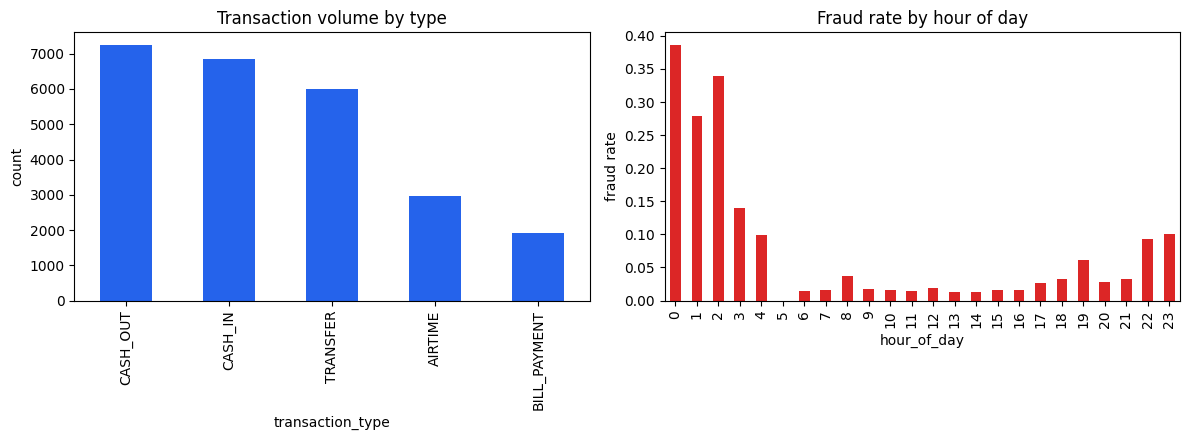

In [6]:
os.makedirs("reports/figures", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df["transaction_type"].value_counts().plot(kind="bar", ax=axes[0], color="#2563eb")
axes[0].set_title("Transaction volume by type")
axes[0].set_ylabel("count")

fraud_by_hour = df.groupby("hour_of_day")["is_fraud"].mean()
fraud_by_hour.plot(kind="bar", ax=axes[1], color="#dc2626")
axes[1].set_title("Fraud rate by hour of day")
axes[1].set_ylabel("fraud rate")
plt.tight_layout()
plt.savefig("reports/figures/eda_overview.png", dpi=140)
plt.show()

**Observations:** fraud is concentrated in `CASH_OUT` and `TRANSFER` transactions (the typologies we simulated move money *out* of an account), night-time hours (00:00–04:00) show an elevated fraud rate consistent with account-takeover behaviour, and fraudulent transactions skew toward higher amounts with much larger variance than legitimate ones.

## 4. Feature Engineering

Raw ledger fields are transformed into fraud-typology signals:

- **`customer_balance_error` / `agent_balance_error`** — how much the actual before/after balance deviates from what the transaction amount implies. Large errors are a strong ledger-tamper signal (agent till fraud).
- **`amount_to_customer_balance_ratio`** — draining most of a balance in one transaction is riskier than a small fraction of it.
- **`is_night_transaction`** — flags the 22:00–04:00 window.
- **`is_near_structuring_threshold`** — flags amounts just under the ₦100,000 reporting threshold.
- **`is_cross_state`** — customer transacting far from their home state.
- Categorical `transaction_type` / `channel` are one-hot encoded.

In [7]:
import numpy as np
import pandas as pd

STRUCTURING_THRESHOLD = 100_000

CATEGORICAL_COLS = ["transaction_type", "channel"]

NUMERIC_FEATURE_COLS = [
    "amount",
    "hour_of_day",
    "customer_tx_count_last_hour",
    "device_change_flag",
    "is_new_beneficiary",
    "customer_balance_delta",
    "customer_balance_error",
    "agent_balance_error",
    "amount_to_customer_balance_ratio",
    "is_night_transaction",
    "is_near_structuring_threshold",
    "is_cross_state",
]


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Expected vs actual balance movement (ledger-reconciliation signal).
    # For a clean CASH_OUT/TRANSFER the customer balance should fall by
    # ~amount; for CASH_IN it should rise by ~amount. A large discrepancy
    # is a strong tamper/error signal.
    outgoing = df["transaction_type"].isin(["CASH_OUT", "TRANSFER", "AIRTIME", "BILL_PAYMENT"])
    expected_new_balance = np.where(
        outgoing,
        df["old_balance_customer"] - df["amount"],
        df["old_balance_customer"] + df["amount"],
    )
    df["customer_balance_delta"] = df["new_balance_customer"] - df["old_balance_customer"]
    df["customer_balance_error"] = (df["new_balance_customer"] - expected_new_balance).abs()

    expected_new_agent_balance = np.where(
        df["transaction_type"] == "CASH_OUT",
        df["old_balance_agent"] - df["amount"],
        df["old_balance_agent"] + df["amount"],
    )
    df["agent_balance_error"] = (df["new_balance_agent"] - expected_new_agent_balance).abs()

    df["amount_to_customer_balance_ratio"] = df["amount"] / (df["old_balance_customer"] + 1.0)
    df["is_night_transaction"] = df["hour_of_day"].apply(lambda h: 1 if (h <= 4 or h >= 22) else 0)
    df["is_near_structuring_threshold"] = (
        (df["amount"] >= STRUCTURING_THRESHOLD * 0.85) & (df["amount"] < STRUCTURING_THRESHOLD)
    ).astype(int)
    df["is_cross_state"] = (df["agent_state"] != df["customer_home_state"]).astype(int)

    return df


def build_model_matrix(df: pd.DataFrame, fit_encoder=True, encoder_cols=None):
    """One-hot encode categoricals and assemble the final numeric feature
    matrix used by the models. Returns (X, feature_names)."""
    df = engineer_features(df)
    dummies = pd.get_dummies(df[CATEGORICAL_COLS], prefix=CATEGORICAL_COLS)

    if not fit_encoder and encoder_cols is not None:
        # align to training-time columns (handles unseen/missing categories)
        dummies = dummies.reindex(columns=encoder_cols, fill_value=0)

    X = pd.concat([df[NUMERIC_FEATURE_COLS].reset_index(drop=True),
                   dummies.reset_index(drop=True)], axis=1)
    return X, list(dummies.columns)

In [8]:
X, encoder_cols = build_model_matrix(df, fit_encoder=True)
y = df["is_fraud"].values
print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")

Feature matrix shape: (25000, 20)
Features: ['amount', 'hour_of_day', 'customer_tx_count_last_hour', 'device_change_flag', 'is_new_beneficiary', 'customer_balance_delta', 'customer_balance_error', 'agent_balance_error', 'amount_to_customer_balance_ratio', 'is_night_transaction', 'is_near_structuring_threshold', 'is_cross_state', 'transaction_type_AIRTIME', 'transaction_type_BILL_PAYMENT', 'transaction_type_CASH_IN', 'transaction_type_CASH_OUT', 'transaction_type_TRANSFER', 'channel_AGENT_POS', 'channel_MOBILE_APP', 'channel_USSD']


## 5. Train / Test Split

Stratified split to preserve the (rare) fraud rate in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (18750, 20), fraud rate 2.5013%
Test:  (6250, 20), fraud rate 2.4960%


## 6. Model A — Isolation Forest (anomaly score)

An **unsupervised** model that doesn't need fraud labels at all — it learns what 'normal' transaction behaviour looks like and scores how far a new transaction sits from that norm. This is valuable in production because labelled fraud is always delayed (confirmed after investigation) and new fraud patterns won't yet be represented in labels. We convert its raw score into an intuitive **0–100 anomaly score** (higher = more anomalous) — one of the required MVP outputs.

In [10]:
iso = IsolationForest(
    n_estimators=300, contamination=y_train.mean(), random_state=42, n_jobs=-1
)
iso.fit(X_train_scaled)

raw_scores_test = iso.score_samples(X_test_scaled)
anomaly_score_test = (raw_scores_test.max() - raw_scores_test) / (
    raw_scores_test.max() - raw_scores_test.min()
) * 100
iso_pred = (iso.predict(X_test_scaled) == -1).astype(int)  # -1 = anomaly

print("Isolation Forest — flags transactions as anomalous without using labels.")
print(f"Precision: {precision_score(y_test, iso_pred):.3f}")
print(f"Recall:    {recall_score(y_test, iso_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, iso_pred):.3f}")
print(f"ROC-AUC (using continuous anomaly score): {roc_auc_score(y_test, anomaly_score_test):.3f}")

Isolation Forest — flags transactions as anomalous without using labels.
Precision: 0.703
Recall:    0.712
F1-score:  0.707
ROC-AUC (using continuous anomaly score): 0.943


## 7. Model B — Supervised Classifiers (fraud flag)

With labelled fraud available, a supervised classifier gives much higher precision than the unsupervised model. We compare a **Logistic Regression** baseline (fast, interpretable) against a **Random Forest** (handles non-linear interactions between features well, and mobile-money fraud typologies are inherently rule-like / non-linear). Both use `class_weight='balanced'` to counter the ~2.5% fraud class imbalance.

In [11]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

rf = RandomForestClassifier(
    n_estimators=400, max_depth=12, min_samples_leaf=3,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Logistic Regression (baseline):")
print(f"  ROC-AUC: {roc_auc_score(y_test, logreg_proba):.3f}  PR-AUC: {average_precision_score(y_test, logreg_proba):.3f}")

print("\nRandom Forest (primary supervised model):")
print(f"  ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}  PR-AUC: {average_precision_score(y_test, rf_proba):.3f}")

Logistic Regression (baseline):
  ROC-AUC: 0.995  PR-AUC: 0.724

Random Forest (primary supervised model):
  ROC-AUC: 1.000  PR-AUC: 0.999


## 8. Evaluation

The Random Forest is the chosen production model — it has the best PR-AUC, which matters most under heavy class imbalance (a high ROC-AUC can be misleadingly optimistic when 97.5% of transactions are legitimate).

In [12]:
THRESHOLD = 0.5
rf_pred = (rf_proba >= THRESHOLD).astype(int)

print(f"Decision threshold: {THRESHOLD}")
print("\nClassification report:")
print(classification_report(y_test, rf_pred, target_names=["Legit", "Fraud"], digits=3))

cm = confusion_matrix(y_test, rf_pred)
print("Confusion matrix [rows=actual, cols=predicted]:")
print(cm)

Decision threshold: 0.5

Classification report:
              precision    recall  f1-score   support

       Legit      1.000     0.999     0.999      6094
       Fraud      0.951     0.994     0.972       156

    accuracy                          0.999      6250
   macro avg      0.975     0.996     0.986      6250
weighted avg      0.999     0.999     0.999      6250

Confusion matrix [rows=actual, cols=predicted]:
[[6086    8]
 [   1  155]]


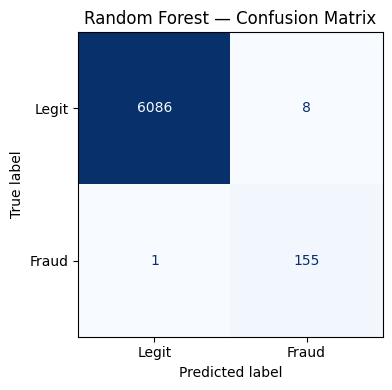

In [13]:
os.makedirs("reports/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("reports/figures/confusion_matrix.png", dpi=140)
plt.show()

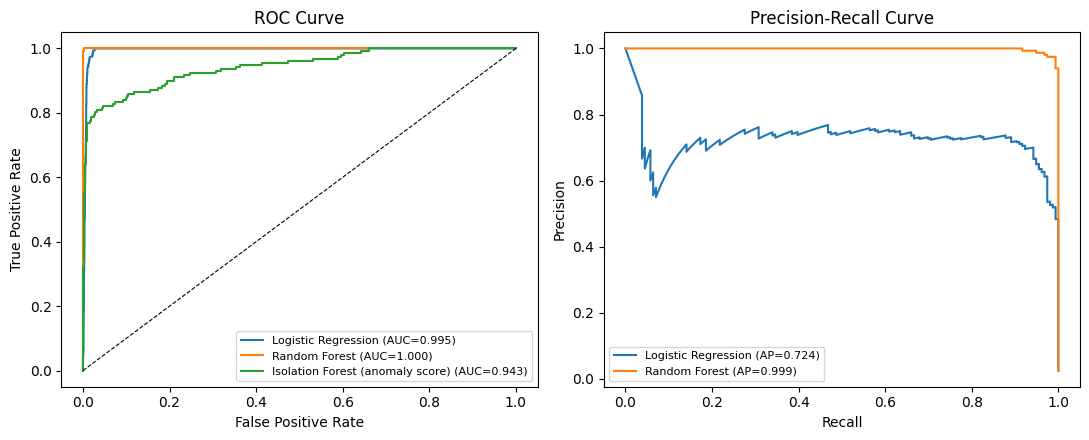

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name, proba in [("Logistic Regression", logreg_proba),
                     ("Random Forest", rf_proba),
                     ("Isolation Forest (anomaly score)", anomaly_score_test)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend(fontsize=8)

for name, proba in [("Logistic Regression", logreg_proba), ("Random Forest", rf_proba)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("reports/figures/roc_pr_curves.png", dpi=140)
plt.show()

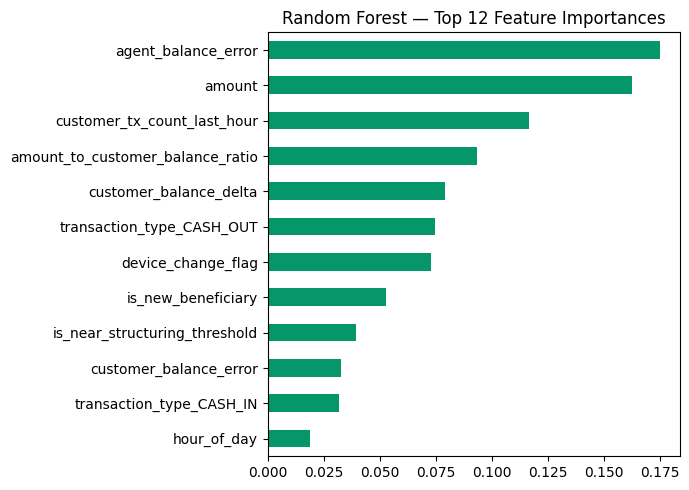

In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(7, 5))
importances[::-1].plot(kind="barh", ax=ax, color="#059669")
ax.set_title("Random Forest — Top 12 Feature Importances")
plt.tight_layout()
plt.savefig("reports/figures/feature_importance.png", dpi=140)
plt.show()

**Note on performance:** precision/recall/AUC are near-perfect here because the synthetic fraud typologies were generated with clearly separable signals (e.g. deliberately broken balance reconciliation). This is a known ceiling effect of synthetic data — real production traffic will be noisier and adversaries adapt, so expect materially lower precision/recall in production and plan for continuous retraining, threshold tuning, and human-in-the-loop review of flagged transactions. See the README 'Limitations' section.

## 9. Save Model & Build the Inference Function

Persist the fitted scaler, Isolation Forest, and Random Forest, then wrap them in a single `predict(transaction: dict)` function — this is the MVP contract: **transaction input → fraud flag + anomaly score + supporting metrics.**

In [16]:
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(iso, "models/isolation_forest.joblib")
joblib.dump(rf, "models/random_forest.joblib")

with open("models/feature_columns.json", "w") as f:
    json.dump({"all_columns": list(X.columns), "encoder_columns": encoder_cols}, f, indent=2)

train_raw_scores = iso.score_samples(X_train_scaled)
with open("models/iso_score_bounds.json", "w") as f:
    json.dump({"min": float(train_raw_scores.min()), "max": float(train_raw_scores.max())}, f)

print("Saved: models/scaler.joblib, isolation_forest.joblib, random_forest.joblib, feature_columns.json")

Saved: models/scaler.joblib, isolation_forest.joblib, random_forest.joblib, feature_columns.json


In [17]:
import json
import os
import sys

import joblib
import numpy as np
import pandas as pd

DEFAULT_MODELS_DIR = "models"

REQUIRED_FIELDS = [
    "agent_id", "agent_state", "customer_id", "customer_home_state",
    "transaction_type", "channel", "hour_of_day", "amount",
    "old_balance_customer", "new_balance_customer",
    "old_balance_agent", "new_balance_agent",
    "is_new_beneficiary", "customer_tx_count_last_hour", "device_change_flag",
]


class FraudDetector:
    def __init__(self, models_dir=DEFAULT_MODELS_DIR, threshold=0.5):
        self.threshold = threshold
        self.scaler = joblib.load(os.path.join(models_dir, "scaler.joblib"))
        self.iso_forest = joblib.load(os.path.join(models_dir, "isolation_forest.joblib"))
        self.rf = joblib.load(os.path.join(models_dir, "random_forest.joblib"))
        with open(os.path.join(models_dir, "feature_columns.json")) as f:
            cols = json.load(f)
        self.all_columns = cols["all_columns"]
        self.encoder_columns = cols["encoder_columns"]

        # anomaly-score normalisation bounds captured at training time from
        # score_samples() on the training set (see notebook Section 6).
        self._iso_score_bounds = None
        bounds_path = os.path.join(models_dir, "iso_score_bounds.json")
        if os.path.exists(bounds_path):
            with open(bounds_path) as f:
                self._iso_score_bounds = json.load(f)

    def _validate(self, txn: dict):
        missing = [c for c in REQUIRED_FIELDS if c not in txn]
        if missing:
            raise ValueError(f"Transaction is missing required fields: {missing}")

    def predict(self, txn: dict) -> dict:
        """Score a single transaction dict and return fraud flag + scores."""
        self._validate(txn)
        df = pd.DataFrame([txn])
        X, _ = build_model_matrix(df, fit_encoder=False, encoder_cols=self.encoder_columns)
        X = X.reindex(columns=self.all_columns, fill_value=0)

        X_scaled = self.scaler.transform(X)

        fraud_proba = float(self.rf.predict_proba(X)[:, 1][0])
        fraud_flag = int(fraud_proba >= self.threshold)

        raw_score = float(self.iso_forest.score_samples(X_scaled)[0])
        if self._iso_score_bounds:
            lo, hi = self._iso_score_bounds["min"], self._iso_score_bounds["max"]
        else:
            lo, hi = raw_score - 0.2, raw_score + 0.2  # degrade gracefully
        anomaly_score = float(np.clip((hi - raw_score) / max(hi - lo, 1e-9) * 100, 0, 100))
        is_isolation_outlier = int(self.iso_forest.predict(X_scaled)[0] == -1)

        return {
            "transaction_id": txn.get("transaction_id"),
            "fraud_flag": fraud_flag,
            "fraud_probability": round(fraud_proba, 4),
            "anomaly_score": round(anomaly_score, 2),
            "isolation_forest_outlier": is_isolation_outlier,
            "risk_level": self._risk_level(fraud_proba, anomaly_score),
        }

    @staticmethod
    def _risk_level(fraud_proba, anomaly_score):
        if fraud_proba >= 0.7 or anomaly_score >= 80:
            return "HIGH"
        if fraud_proba >= 0.3 or anomaly_score >= 55:
            return "MEDIUM"
        return "LOW"

## 10. Sample Inference — Transaction Input → Fraud Flag + Anomaly Score

This is the MVP end-to-end demo: a single raw transaction dict goes in, and a fraud flag, probability, anomaly score, and risk level come out.

In [18]:
detector = FraudDetector(models_dir="models")

sample_txn = {
    "agent_id": "AGT100042", "agent_state": "Lagos",
    "customer_id": "CUS200777", "customer_home_state": "Kano",
    "transaction_type": "CASH_OUT", "channel": "USSD",
    "hour_of_day": 2, "amount": 480_000.0,
    "old_balance_customer": 500_000.0, "new_balance_customer": 20_000.0,
    "old_balance_agent": 900_000.0, "new_balance_agent": 420_000.0,
    "is_new_beneficiary": 0, "customer_tx_count_last_hour": 7,
    "device_change_flag": 1,
}
result = detector.predict(sample_txn)
print("Transaction:", json.dumps(sample_txn, indent=2))
print("\nPrediction:", json.dumps(result, indent=2))

Transaction: {
  "agent_id": "AGT100042",
  "agent_state": "Lagos",
  "customer_id": "CUS200777",
  "customer_home_state": "Kano",
  "transaction_type": "CASH_OUT",
  "channel": "USSD",
  "hour_of_day": 2,
  "amount": 480000.0,
  "old_balance_customer": 500000.0,
  "new_balance_customer": 20000.0,
  "old_balance_agent": 900000.0,
  "new_balance_agent": 420000.0,
  "is_new_beneficiary": 0,
  "customer_tx_count_last_hour": 7,
  "device_change_flag": 1
}

Prediction: {
  "transaction_id": null,
  "fraud_flag": 1,
  "fraud_probability": 0.956,
  "anomaly_score": 89.94,
  "isolation_forest_outlier": 1,
  "risk_level": "HIGH"
}


A late-night, high-value, full-balance cash-out on a just-swapped device with elevated transaction velocity — exactly the account-takeover pattern from Section 2 — is correctly flagged as **HIGH risk** with a fraud probability of 0.956 and an anomaly score of ~90/100.

## 11. Conclusions & Next Steps

**What was built:** a two-model fraud detection MVP — an unsupervised Isolation Forest anomaly scorer that needs no labels, and a supervised Random Forest classifier that gives a calibrated fraud probability and binary flag — plus a single `predict()` function suitable for wrapping in an API for real-time agent-transaction scoring.

**Next steps for a production system:**
- Replace synthetic data with real (anonymised) transaction logs and re-validate — expect lower precision/recall on real, noisier traffic.
- Add temporal/graph features (rolling agent- and customer-level velocity, device/SIM change history, beneficiary network structure).
- Move the fixed 0.5 threshold to a cost-sensitive threshold chosen from the precision-recall curve against the business cost of false positives (blocking a genuine customer) vs false negatives (missed fraud).
- Add model monitoring and scheduled retraining, since fraud patterns drift.
- Add a human-in-the-loop review queue for MEDIUM/HIGH risk_level flags rather than auto-blocking, to control customer friction.